# 05 · API REST : requêtes, erreurs et pagination

Une **API REST** est une « porte d'entrée » qu'un service ouvre sur ses données : votre programme lui envoie une **requête HTTP** (comme le fait un navigateur), et elle répond avec des données structurées, le plus souvent au format **JSON**. Ce notebook passe à la pratique avec deux API publiques, gratuites et **sans clé** : la Banque mondiale et Open-Meteo.

> 🎯 **Cas d'usage**
>
> Une ONG qui travaille en Afrique de l'Ouest prépare une note sur les 8 pays de l'**UEMOA** (Union économique et monétaire ouest-africaine) : Bénin, Burkina Faso, Côte d'Ivoire, Guinée-Bissau, Mali, Niger, Sénégal et Togo.
>
> Elle vous demande : (1) la **population** et le **PIB par habitant** de **2000 à 2024**, depuis l'API de la **Banque mondiale** ; (2) la **météo de la semaine** dans cinq grandes villes, depuis l'API **Open-Meteo**, pour organiser des missions sur le terrain.
>
> Livrables : des **fichiers propres et datés** (réponses brutes en JSON + tableaux Parquet), réutilisables par toute l'équipe.

**Ce que vous allez apprendre**
- envoyer une requête `GET` avec `requests` (paramètres, en-têtes, délai maximal) et lire la réponse JSON ;
- lire un code HTTP (200, 400, 404, 429…) et gérer les erreurs proprement ;
- vous méfier d'un « 200 » qui cache une erreur ;
- récupérer **toutes les pages** d'un résultat paginé, poliment (pauses, nouveaux essais) ;
- passer du **brut** (bronze) au **propre** (silver) : JSON daté → DataFrame → Parquet ;
- comprendre comment on s'authentifie avec une clé d'API sans l'écrire dans le code.

**Durée indicative** : 25 minutes (+ 15 minutes si vous faites tous les exercices).

**Prérequis**
- Python de base et pandas (un `DataFrame`, `head()`, filtrer des lignes) ;
- une connexion Internet (aucun compte ni clé d'API n'est nécessaire) ;
- le cours sur les API REST (verbes, codes HTTP, pagination) et sur le data lake (bronze / silver).

**Mode d'emploi** : exécutez les cellules dans l'ordre (Maj + Entrée). Les résultats météo changent chaque jour : vos chiffres ne seront pas exactement ceux de la version corrigée.

## 1. Préparer l'environnement

On importe les bibliothèques :
- `requests` envoie les requêtes HTTP ;
- `pandas` range les résultats dans des tableaux ;
- `json` écrit les réponses brutes dans des fichiers ;
- `time` permet de faire des **pauses** entre deux requêtes ;
- `dotenv` lit le fichier `.env` (utile à la section 11, pour les clés d'API) ;
- les autres servent plus loin : `pathlib` (chemins), `datetime` (date du jour), `matplotlib` (graphiques), `os` (variables d'environnement) et `math` (exercice 2).

In [1]:
import json
import math
import os
import time
from datetime import date
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import requests
from dotenv import load_dotenv

Comme dans le cours sur le **data lake**, on range :
- les réponses **brutes**, telles que l'API les a envoyées, dans `data/raw/` (couche *bronze*) ;
- les tableaux **propres** dans `data/processed/` (couche *silver*).

La date du jour servira à **nommer les fichiers** : on saura toujours de quand datent les données.

In [2]:
DOSSIER_DATA = Path("../data")
DOSSIER_BRUT = DOSSIER_DATA / "raw" / "api"
DOSSIER_PROPRE = DOSSIER_DATA / "processed"
DOSSIER_BRUT.mkdir(parents=True, exist_ok=True)
DOSSIER_PROPRE.mkdir(parents=True, exist_ok=True)

AUJOURDHUI = date.today().isoformat()     # ex. '2026-10-07'
print("Bruts   :", DOSSIER_BRUT)
print("Propres :", DOSSIER_PROPRE)
print("Date    :", AUJOURDHUI)

Bruts   : ../data/raw/api
Propres : ../data/processed
Date    : 2026-10-07


Deux réglages accompagneront **chaque** requête :
- l'en-tête **User-Agent** : la « carte de visite » de notre programme. Un nom clair permet à l'administrateur de l'API de savoir qui l'appelle (règle de politesse vue en cours ; en production, on y ajoute une adresse de contact) ;
- le **délai maximal** (*timeout*) : sans lui, un programme peut attendre une réponse… indéfiniment.

> ⚠️ **Pas d'accents dans un en-tête HTTP** : les en-têtes doivent rester en ASCII (lettres sans accents). Testé pour ce TP : avec « données » dans le User-Agent, l'API de la Banque mondiale répond **403** (accès interdit) au lieu de 200.

On prépare aussi cinq couleurs pour les graphiques (une palette lisible par les personnes daltoniennes).

In [3]:
# Notre « carte de visite », envoyée avec chaque requête
EN_TETES = {"User-Agent": "cours-AMA (TP Sources de donnees ; usage pedagogique)"}

# Délai maximal d'attente d'une réponse, en secondes
DELAI_MAX = 60

# Couleurs des courbes (dans cet ordre)
COULEURS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]

## 2. Premier appel : la météo de Cotonou

Open-Meteo donne des prévisions météo pour n'importe quel point du globe. On l'interroge à une adresse fixe, l'**endpoint** (`/v1/forecast`), en précisant notre demande avec des **paramètres** : la latitude et la longitude de Cotonou, les variables voulues par jour (`daily`) et le fuseau horaire.

On ne colle pas les paramètres à la main dans l'URL : on les donne dans un dictionnaire `params`, et `requests` construit l'URL complète pour nous.

In [4]:
URL_METEO = "https://api.open-meteo.com/v1/forecast"

parametres = {
    "latitude": 6.37,                 # Cotonou
    "longitude": 2.39,
    "daily": "temperature_2m_max,temperature_2m_min,precipitation_sum",
    "timezone": "auto",               # dates à l'heure locale
}
reponse = requests.get(URL_METEO, params=parametres, headers=EN_TETES, timeout=DELAI_MAX)

Avant de lire les données, on regarde l'**enveloppe** de la réponse : le **code HTTP** (le verdict du serveur, 200 = OK), le **type de contenu** annoncé par le serveur, et l'URL complète que `requests` a construite.

In [5]:
print("Code HTTP       :", reponse.status_code)
print("Type de contenu :", reponse.headers["Content-Type"])
print("URL appelée     :", reponse.url)

Code HTTP       : 200
Type de contenu : application/json; charset=utf-8
URL appelée     : https://api.open-meteo.com/v1/forecast?latitude=6.37&longitude=2.39&daily=temperature_2m_max%2Ctemperature_2m_min%2Cprecipitation_sum&timezone=auto


> 💡 Dans l'URL, les virgules sont devenues `%2C` : c'est l'**encodage URL** des caractères spéciaux, fait automatiquement par `requests`. Vous pouvez copier cette URL dans votre navigateur pour voir la réponse brute.

Le contenu est du **JSON** (`application/json`). La méthode `reponse.json()` le transforme en dictionnaire Python. Regardons ses clés.

In [6]:
donnees = reponse.json()          # texte JSON → dictionnaire Python
print("Clés     :", list(donnees.keys()))
print("Fuseau   :", donnees["timezone"])
print("Unités   :", donnees["daily_units"])

Clés     : ['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'daily_units', 'daily']
Fuseau   : Africa/Porto-Novo
Unités   : {'time': 'iso8601', 'temperature_2m_max': '°C', 'temperature_2m_min': '°C', 'precipitation_sum': 'mm'}


Les prévisions sont dans `donnees["daily"]` : un dictionnaire de **listes de même longueur** (une liste par variable, une case par jour). C'est exactement ce qu'attend `pd.DataFrame` : on obtient un tableau d'une ligne par jour. On convertit la colonne `time` (du texte) en vraie date et on donne des noms de colonnes en français.

In [7]:
previsions = pd.DataFrame(donnees["daily"])
previsions["time"] = pd.to_datetime(previsions["time"])     # texte → date
previsions = previsions.rename(columns={
    "time": "date",
    "temperature_2m_max": "temp_max_c",
    "temperature_2m_min": "temp_min_c",
    "precipitation_sum": "pluie_mm",
})
previsions

,date,temp_max_c,temp_min_c,pluie_mm
0,2026-10-07,29.5,26.1,0.5
1,2026-10-08,28.6,24.9,3.0
2,2026-10-09,29.3,25.3,0.5
3,2026-10-10,28.6,26.1,1.9
4,2026-10-11,29.4,25.8,0.0
5,2026-10-12,29.3,26.2,0.3
6,2026-10-13,29.7,25.7,0.9


## 3. Anatomie d'un échange HTTP… et les erreurs

Reprenons notre appel avec le vocabulaire du cours :

| Élément | Dans notre appel | Rôle |
|---|---|---|
| **Verbe** (méthode) | `GET` | lire une ressource (`POST` = créer, `PUT`/`PATCH` = modifier, `DELETE` = supprimer) |
| **Ressource** (endpoint) | `https://api.open-meteo.com/v1/forecast` | *quoi* on demande |
| **Paramètres** | `latitude`, `longitude`, `daily`… | préciser la demande (après le `?` dans l'URL) |
| **En-têtes** (*headers*) | `User-Agent: cours-AMA (…)` | informations sur la requête : qui appelle, format, clé d'API… |
| **Code HTTP** | `200` | le verdict du serveur |
| **Corps** (*body*) | le JSON | les données |

On peut retrouver ce que **nous** avons envoyé dans `reponse.request`, et lire les en-têtes de la **réponse** dans `reponse.headers` :

In [8]:
print("Verbe envoyé      :", reponse.request.method)
print("User-Agent envoyé :", reponse.request.headers["User-Agent"])
print("Date du serveur   :", reponse.headers["Date"])

Verbe envoyé      : GET
User-Agent envoyé : cours-AMA (TP Sources de donnees ; usage pedagogique)
Date du serveur   : Wed, 07 Oct 2026 12:57:14 GMT


Les principaux **codes HTTP** :

| Code | Signification | Que faire ? |
|---|---|---|
| 200 | OK | lire les données |
| 400 | Requête invalide (paramètre faux) | corriger la requête ; réessayer ne sert à rien |
| 401 / 403 | Non authentifié / accès interdit | vérifier la clé d'API, les droits |
| 404 | Ressource introuvable | vérifier l'URL |
| 429 | Trop de requêtes (*Too Many Requests*) | **ralentir** : attendre, puis réessayer |
| 500 / 503 | Erreur ou surcharge du serveur | réessayer un peu plus tard |

> 💡 Règle simple : **4xx = l'erreur vient de nous** (on corrige la requête), **5xx = l'erreur vient du serveur** (on peut réessayer). Le **429** est l'exception : c'est un 4xx qu'on peut réessayer… après une pause.

Provoquons une erreur **400** : une latitude de 999° n'existe pas. Le serveur refuse et explique pourquoi dans le JSON (clé `reason`).

In [9]:
parametres_faux = {"latitude": 999, "longitude": 2.39, "daily": "temperature_2m_max"}
reponse_400 = requests.get(URL_METEO, params=parametres_faux, headers=EN_TETES, timeout=DELAI_MAX)

print("Code HTTP :", reponse_400.status_code)
print("Contenu   :", reponse_400.json())

Code HTTP : 400
Contenu   : {'error': True, 'reason': 'Latitude must be in range of -90 to 90°. Given: 999.0.'}


Puis une erreur **404** : une faute de frappe dans l'endpoint (`forecas` au lieu de `forecast`). Le corps d'une erreur n'est pas toujours du JSON (c'est souvent une page HTML) : on l'affiche donc comme du simple texte, avec `reponse.text`.

In [10]:
url_fausse = "https://api.open-meteo.com/v1/forecas"
reponse_404 = requests.get(url_fausse, params=parametres, headers=EN_TETES, timeout=DELAI_MAX)

print("Code HTTP :", reponse_404.status_code)
print("Contenu   :", reponse_404.text)

Code HTTP : 404
Contenu   : {"error":true,"reason":"Not Found"}


> ⚠️ `requests` **ne s'arrête pas** tout seul sur un 400 ou un 404 : si on ne vérifie rien, le programme continue avec une réponse qui ne contient pas de données.

La méthode `raise_for_status()` transforme un code 4xx ou 5xx en **exception** Python (une erreur qui interrompt le programme). On l'entoure d'un `try / except` pour afficher un message lisible au lieu d'une longue trace d'erreur.

In [11]:
try:
    reponse_test = requests.get(URL_METEO, params=parametres_faux, headers=EN_TETES, timeout=DELAI_MAX)
    reponse_test.raise_for_status()           # exception si code 4xx ou 5xx
    print("Tout va bien :", reponse_test.json())
except requests.exceptions.HTTPError as erreur:
    print("Erreur HTTP  :", erreur)
    print("Explication  :", reponse_test.json()["reason"])
except requests.exceptions.RequestException as erreur:    # réseau coupé, délai dépassé…
    print("Problème réseau :", erreur)

Erreur HTTP  : 400 Client Error: Bad Request for url: https://api.open-meteo.com/v1/forecast?latitude=999&longitude=2.39&daily=temperature_2m_max
Explication  : Latitude must be in range of -90 to 90°. Given: 999.0.


## 4. Banque mondiale : une page = `[meta, données]`

L'API de la Banque mondiale suit le modèle `https://api.worldbank.org/v2/fr/country/{pays}/indicator/{indicateur}` :
- `fr` : la langue des libellés. Les noms de pays arrivent en français (« Côte d'Ivoire », « Sénégal ») ; sans `fr/`, ils arrivent en anglais ;
- `{pays}` : un ou plusieurs codes ISO à 2 lettres, séparés par `;` (ex. `BJ;SN;TG`) ;
- `{indicateur}` : le code de la série, ici `SP.POP.TOTL` (population totale).

Paramètres utiles : `format=json` (sans lui, l'API répond en XML !), `date=2000:2024` (période), `per_page` (lignes par page) et `page` (numéro de page).

Pourquoi des pages ? Quand un résultat est gros, l'API le découpe en **pages**, comme un livre : il faut demander la page 1, puis la 2, etc. C'est la **pagination**. Ici : 8 pays × 25 années = 200 lignes. On demande volontairement **50 lignes par page** pour voir la pagination à l'œuvre.

In [12]:
# Les 8 pays de l'UEMOA (codes ISO à 2 lettres)
PAYS_UEMOA = ["BJ", "BF", "CI", "GW", "ML", "NE", "SN", "TG"]
codes_pays = ";".join(PAYS_UEMOA)          # 'BJ;BF;CI;GW;ML;NE;SN;TG'

URL_POPULATION = f"https://api.worldbank.org/v2/fr/country/{codes_pays}/indicator/SP.POP.TOTL"
print(URL_POPULATION)

https://api.worldbank.org/v2/fr/country/BJ;BF;CI;GW;ML;NE;SN;TG/indicator/SP.POP.TOTL


On demande **seulement la page 1** et on regarde la forme de la réponse :

In [13]:
parametres_bm = {"format": "json", "date": "2000:2024", "per_page": 50, "page": 1}
reponse_bm = requests.get(URL_POPULATION, params=parametres_bm, headers=EN_TETES, timeout=DELAI_MAX)
reponse_bm.raise_for_status()

page_1 = reponse_bm.json()
print("Type de la réponse :", type(page_1))
print("Nombre d'éléments  :", len(page_1))

Type de la réponse : <class 'list'>
Nombre d'éléments  : 2


Ce n'est pas un dictionnaire mais une **liste de 2 éléments** : `[meta, données]`.
- `meta` (les **métadonnées**, des « données sur les données ») décrit le résultat : numéro de page, nombre de pages, lignes par page, nombre total de lignes, date de mise à jour ;
- `données` est la liste des lignes **de cette page seulement**.

In [14]:
meta, lignes_page_1 = page_1         # on « déballe » la liste en deux variables
print("Métadonnées :", meta)
print(f"Page {meta['page']} sur {meta['pages']} | {meta['per_page']} lignes par page | {meta['total']} lignes au total")
print("Lignes reçues sur cette page :", len(lignes_page_1))

Métadonnées : {'page': 1, 'pages': 4, 'per_page': 50, 'total': 200, 'sourceid': '2', 'lastupdated': '2026-07-13'}
Page 1 sur 4 | 50 lignes par page | 200 lignes au total
Lignes reçues sur cette page : 50


Voici **une** ligne. Remarquez : le pays est un dictionnaire imbriqué (code `id` + nom en français dans `value`), l'année `date` est du **texte**, et `value` vaudra `None` si la donnée manque.

In [15]:
print(json.dumps(lignes_page_1[0], indent=2, ensure_ascii=False))

{
  "indicator": {
    "id": "SP.POP.TOTL",
    "value": "Population, total"
  },
  "country": {
    "id": "BJ",
    "value": "Bénin"
  },
  "countryiso3code": "BEN",
  "date": "2024",
  "value": 14462724,
  "unit": "",
  "obs_status": "",
  "decimal": 0
}


> 💡 200 lignes au total, 50 par page → **4 pages**. Une seule requête ne suffit pas : il faudra une boucle (section 7).

## 5. Piège : « 200 » ne veut pas toujours dire « succès »

Testons un code pays qui n'existe pas : `ZZ`. On s'attendrait à une erreur 404… Voyons :

In [16]:
url_pays_invalide = "https://api.worldbank.org/v2/fr/country/ZZ/indicator/SP.POP.TOTL"
reponse_zz = requests.get(url_pays_invalide, params={"format": "json"}, headers=EN_TETES, timeout=DELAI_MAX)
reponse_zz.raise_for_status()             # ne dit rien : le code est 200 !

print("Code HTTP :", reponse_zz.status_code)
print("Contenu   :", reponse_zz.json())

Code HTTP : 200
Contenu   : [{'message': [{'id': '120', 'key': 'Invalid value', 'value': 'The provided parameter value is not valid'}]}]


> ⚠️ Le code est **200** (« OK ») et `raise_for_status()` ne voit rien… mais le contenu est un **message d'erreur**, en anglais (« la valeur du paramètre n'est pas valide »). Le transport HTTP s'est bien passé, la demande, elle, est fausse. Certaines API fonctionnent ainsi.
>
> Autre variante : pour certains codes inconnus, l'API répond 200 avec `total = 0` et `None` à la place des données (vous le verrez à l'exercice 3).

Conclusion : il faut **aussi vérifier le contenu**. On écrit une petite fonction réutilisable, qui renvoie `(meta, lignes)` si tout va bien et lève une erreur sinon :

In [17]:
def verifier_reponse_bm(contenu):
    """Vérifie une réponse de la Banque mondiale et renvoie (meta, lignes).
    Lève une erreur si l'API a renvoyé un message d'erreur (même avec un code 200)."""
    if "message" in contenu[0]:
        raise ValueError("erreur de l'API : " + contenu[0]["message"][0]["value"])
    meta, lignes = contenu
    if lignes is None:          # demande acceptée mais aucune donnée
        lignes = []
    return meta, lignes

On la teste sur la réponse précédente :

In [18]:
try:
    meta_zz, lignes_zz = verifier_reponse_bm(reponse_zz.json())
    print("Lignes reçues :", len(lignes_zz))
except ValueError as erreur:
    print("Problème détecté :", erreur)

Problème détecté : erreur de l'API : The provided parameter value is not valid


## 6. Être poli et robuste : délai maximal, nouveaux essais, code 429

Une API publique est partagée par des milliers d'utilisateurs (et ici, par toute la classe **en même temps**). Trois situations doivent être prévues :
1. **Serveur injoignable ou trop lent** : la connexion échoue, ou le délai maximal est dépassé. → on réessaie.
2. **429 *Too Many Requests*** : on a envoyé trop de requêtes trop vite, le serveur demande de ralentir. Il indique souvent combien de secondes attendre dans l'en-tête **`Retry-After`**. → on attend, puis on réessaie.
3. **5xx** : panne passagère du serveur. → on réessaie un peu plus tard.

Pour les autres erreurs (400, 404…), réessayer ne sert à rien : la requête est fausse.

La stratégie classique : **3 essais maximum**, avec des pauses de plus en plus longues (2 s, puis 4 s). C'est le *backoff exponentiel* (« recul exponentiel ») : si 30 étudiants saturent l'API, chacun ralentit au lieu d'insister.

In [19]:
CODES_A_REESSAYER = [429, 500, 502, 503, 504]

def get_poli(url, params=None, essais_max=3):
    """Requête GET « polie » : User-Agent, délai maximal et jusqu'à 3 essais
    si le serveur est saturé (429), en panne (5xx) ou injoignable."""
    for essai in range(1, essais_max + 1):
        pause = 2 ** essai                         # 2 s, puis 4 s
        try:
            reponse = requests.get(url, params=params, headers=EN_TETES, timeout=DELAI_MAX)
            if reponse.status_code not in CODES_A_REESSAYER:
                reponse.raise_for_status()         # 400, 404… : on s'arrête tout de suite
                return reponse                     # succès : on sort de la fonction
            print(f"  essai {essai} : code {reponse.status_code}")
            attente = reponse.headers.get("Retry-After", "")
            if attente.isdigit():                  # le serveur a dit combien attendre
                pause = min(int(attente), 60)      # … sans dépasser 1 minute
        except (requests.exceptions.ConnectionError, requests.exceptions.Timeout):
            print(f"  essai {essai} : serveur injoignable ou trop lent")
        if essai < essais_max:
            print(f"  → nouvel essai dans {pause} s")
            time.sleep(pause)
    raise RuntimeError(f"échec après {essais_max} essais : {url}")

Premier test : un appel normal. Il réussit du premier coup, donc `get_poli` n'affiche rien.

In [20]:
reponse = get_poli(URL_METEO, parametres)
print("Code :", reponse.status_code, "| jours de prévision :", len(reponse.json()["daily"]["time"]))

Code : 200 | jours de prévision : 7


Deuxième test : un serveur **injoignable**. Pour le simuler sans déranger personne, on appelle notre propre machine (`localhost`) sur un port où aucun programme n'écoute : la connexion est refusée à chaque fois. On voit les 3 essais, avec 2 s puis 4 s de pause (au moins 6 secondes d'attente, un peu plus sous Windows).

In [21]:
try:
    get_poli("http://localhost:9/api-qui-n-existe-pas")
except RuntimeError as erreur:
    print("Abandon :", erreur)

  essai 1 : serveur injoignable ou trop lent
  → nouvel essai dans 2 s


  essai 2 : serveur injoignable ou trop lent
  → nouvel essai dans 4 s


  essai 3 : serveur injoignable ou trop lent
Abandon : échec après 3 essais : http://localhost:9/api-qui-n-existe-pas


> 💡 **Et le 429 ?** On ne le provoque pas exprès : il faudrait bombarder une API de requêtes, ce qui est justement impoli. Mais notre fonction est prête : si le serveur répond 429 avec `Retry-After: 30`, elle attend 30 secondes ; sans cet en-tête, elle attend 2 s puis 4 s. Open-Meteo, par exemple, limite son usage gratuit à 600 appels par minute et 10 000 par jour. Ces limites sont comptées **par adresse IP**, et une salle de classe sort souvent sur Internet par **une seule** adresse IP : une classe qui relance ses cellules en boucle peut donc les atteindre.

> ⚠️ L'API de la Banque mondiale répond en général en moins d'une seconde, mais quand elle est chargée, une page peut mettre **plusieurs dizaines de secondes** (constaté pendant la préparation de ce TP : 50 s pour une page). D'où un délai maximal généreux (60 s) et les nouveaux essais. Si une cellule semble bloquée, patientez avant de la relancer.

## 7. Pagination : récupérer toutes les pages

Principe de la boucle :
1. demander la page 1 et lire dans `meta` le **nombre de pages** ;
2. **tant que** la page courante ≤ nombre de pages : demander la page, ajouter ses lignes à une liste, passer à la page suivante (avec une courte **pause** de politesse) ;
3. à la fin, **vérifier** que le nombre de lignes reçues = `total` annoncé.

On réutilise `get_poli` (pour les erreurs réseau et le 429) et `verifier_reponse_bm` (pour le piège du 200).

In [22]:
def recuperer_toutes_les_pages(url, params):
    """Récupère toutes les pages d'un résultat Banque mondiale et renvoie la liste de toutes les lignes."""
    params = dict(params)            # copie : on ne modifie pas le dictionnaire reçu
    toutes_les_lignes = []
    page = 1
    nb_pages = 1                     # inconnu avant la 1re réponse : on suppose 1
    while page <= nb_pages:
        params["page"] = page
        meta, lignes = verifier_reponse_bm(get_poli(url, params).json())
        nb_pages = meta["pages"]     # le vrai nombre de pages, lu dans les métadonnées
        toutes_les_lignes.extend(lignes)
        print(f"  page {page}/{nb_pages} : {len(lignes)} lignes")
        page = page + 1
        time.sleep(0.5)              # pause de politesse entre deux pages
    if len(toutes_les_lignes) != meta["total"]:
        raise ValueError(f"{len(toutes_les_lignes)} lignes reçues au lieu de {meta['total']}")
    print(f"Terminé : {len(toutes_les_lignes)} lignes (total annoncé : {meta['total']})")
    return toutes_les_lignes

On l'utilise pour la population des 8 pays, avec 50 lignes par page :

In [23]:
PARAMS_BM = {"format": "json", "date": "2000:2024", "per_page": 50}

lignes_population = recuperer_toutes_les_pages(URL_POPULATION, PARAMS_BM)

  page 1/4 : 50 lignes


  page 2/4 : 50 lignes


  page 3/4 : 50 lignes


  page 4/4 : 50 lignes


Terminé : 200 lignes (total annoncé : 200)


Contrôle : on attend 8 pays × 25 années (2000 à 2024).

In [24]:
attendu = len(PAYS_UEMOA) * 25
print("Lignes reçues :", len(lignes_population), "| attendues :", attendu)
print("Complet :", len(lignes_population) == attendu)

Lignes reçues : 200 | attendues : 200
Complet : True


## 8. Bronze → silver : JSON brut daté, puis tableau propre

Rappel du cours : **garder le brut tel quel**, daté, avec sa source. Si on se trompe plus tard dans le nettoyage, on repart du brut sans réinterroger l'API.

On enregistre donc les lignes reçues dans un fichier JSON, avec quelques informations de **traçabilité** : source, paramètres, date d'extraction et **licence** (les données de la Banque mondiale sont sous licence CC BY 4.0 : réutilisation libre en citant la source).

In [25]:
def sauvegarder_brut(lignes, indicateur, url, params):
    """Écrit les lignes brutes et leur traçabilité dans data/raw/api/worldbank/, dans un fichier daté."""
    dossier = DOSSIER_BRUT / "worldbank"
    dossier.mkdir(parents=True, exist_ok=True)
    chemin = dossier / f"{indicateur}_uemoa_{AUJOURDHUI}.json"
    contenu = {"source": url, "parametres": params, "date_extraction": AUJOURDHUI,
               "licence": "CC BY 4.0 - Banque mondiale", "lignes": lignes}
    chemin.write_text(json.dumps(contenu, ensure_ascii=False, indent=1), encoding="utf-8")
    print(f"Brut sauvegardé : {chemin} ({chemin.stat().st_size / 1024:.0f} Ko)")

On l'applique aux lignes de population :

In [26]:
sauvegarder_brut(lignes_population, "SP.POP.TOTL", URL_POPULATION, PARAMS_BM)

Brut sauvegardé : ../data/raw/api/worldbank/SP.POP.TOTL_uemoa_2026-10-07.json (54 Ko)


**Aplatir** (*flatten*) : chaque ligne JSON contient des dictionnaires imbriqués. On ne garde que ce qui nous intéresse, dans des colonnes simples et bien **typées** :
- `pays` (nom), `iso3` (code à 3 lettres) ;
- `annee` en **entier** (et non en texte : on pourra trier, filtrer, calculer) ;
- `valeur` en **nombre décimal** ; une valeur absente (`None`) devient `NaN` (*Not a Number*), la valeur manquante de pandas.

In [27]:
def aplatir_bm(lignes):
    """Transforme les lignes JSON de la Banque mondiale en DataFrame propre."""
    enregistrements = []
    for ligne in lignes:
        enregistrements.append({
            "pays": ligne["country"]["value"],
            "iso3": ligne["countryiso3code"],
            "annee": int(ligne["date"]),        # '2024' → 2024
            "valeur": ligne["value"],           # None si la donnée manque
        })
    tableau = pd.DataFrame(enregistrements)
    tableau["valeur"] = tableau["valeur"].astype(float)    # None → NaN
    return tableau.sort_values(["iso3", "annee"]).reset_index(drop=True)

On l'applique à la population, puis on vérifie le **type** de chaque colonne (`dtypes`) : `annee` doit être un entier (`int64`) et `valeur` un décimal (`float64`).

In [28]:
population = aplatir_bm(lignes_population)
print(population.dtypes)
population.head()

pays          str
iso3          str
annee       int64
valeur    float64
dtype: object


,pays,iso3,annee,valeur
0,Bénin,BEN,2000,7221619.0
1,Bénin,BEN,2001,7445596.0
2,Bénin,BEN,2002,7675426.0
3,Bénin,BEN,2003,7913070.0
4,Bénin,BEN,2004,8159094.0


Contrôles qualité rapides : nombre de lignes, valeurs manquantes, années et pays couverts.

In [29]:
print("Lignes             :", len(population))
print("Valeurs manquantes :", population["valeur"].isna().sum())
print("Années             :", population["annee"].min(), "→", population["annee"].max())
print("Pays               :", population["pays"].nunique())

Lignes             : 200
Valeurs manquantes : 0
Années             : 2000 → 2024
Pays               : 8


> 💡 Ici, aucune valeur manquante. Ce n'est pas toujours le cas : le **taux de pauvreté** (`SI.POV.DDAY`, % de la population vivant avec moins de 3 $ par jour, en parité de pouvoir d'achat) n'est mesuré que lors de grandes enquêtes auprès des ménages, espacées de plusieurs années. Mêmes fonctions, autre indicateur, pour le Bénin :

In [30]:
url_pauvrete = "https://api.worldbank.org/v2/fr/country/BJ/indicator/SI.POV.DDAY"
pauvrete = aplatir_bm(recuperer_toutes_les_pages(url_pauvrete, PARAMS_BM))

print("Valeurs manquantes :", pauvrete["valeur"].isna().sum(), "sur", len(pauvrete))
pauvrete.dropna()          # on n'affiche que les années mesurées

  page 1/1 : 25 lignes


Terminé : 25 lignes (total annoncé : 25)
Valeurs manquantes : 20 sur 25


,pays,iso3,annee,valeur
3,Bénin,BEN,2003,70.5
11,Bénin,BEN,2011,68.4
15,Bénin,BEN,2015,65.8
18,Bénin,BEN,2018,37.2
21,Bénin,BEN,2021,27.2


> ⚠️ Ne remplacez **pas** une valeur manquante par 0 : « pas mesuré » ne veut pas dire « 0 % de pauvres ». On garde `NaN` et on le signale dans la note.

## 9. Deux indicateurs fusionnés : population et PIB par habitant

On applique exactement la même chaîne (pagination → brut → aplatir) au **PIB par habitant** (`NY.GDP.PCAP.CD`, en dollars US courants). C'est tout l'intérêt d'avoir écrit des fonctions.

In [31]:
URL_PIB = f"https://api.worldbank.org/v2/fr/country/{codes_pays}/indicator/NY.GDP.PCAP.CD"

lignes_pib = recuperer_toutes_les_pages(URL_PIB, PARAMS_BM)
sauvegarder_brut(lignes_pib, "NY.GDP.PCAP.CD", URL_PIB, PARAMS_BM)
pib = aplatir_bm(lignes_pib)

  page 1/4 : 50 lignes


  page 2/4 : 50 lignes


  page 3/4 : 50 lignes


  page 4/4 : 50 lignes


Terminé : 200 lignes (total annoncé : 200)
Brut sauvegardé : ../data/raw/api/worldbank/NY.GDP.PCAP.CD_uemoa_2026-10-07.json (59 Ko)


**Fusion** : on rassemble les deux tableaux sur la clé (`iso3`, `pays`, `annee`), comme une **jointure** en SQL. On renomme d'abord `valeur` pour savoir quelle colonne contient quoi. `how="outer"` garde une année même si l'un des deux indicateurs y est absent (le résultat est trié selon la clé : par code pays, puis par année).

In [32]:
uemoa = pd.merge(
    population.rename(columns={"valeur": "population"}),
    pib.rename(columns={"valeur": "pib_par_habitant_usd"}),
    on=["iso3", "pays", "annee"],
    how="outer",
)
print("Lignes :", len(uemoa), "| PIB manquants :", uemoa["pib_par_habitant_usd"].isna().sum())
uemoa.tail()

Lignes : 200 | PIB manquants : 0


,pays,iso3,annee,population,pib_par_habitant_usd
195,Togo,TGO,2020,7788054.0,961.219781
196,Togo,TGO,2021,7936176.0,1076.295201
197,Togo,TGO,2022,8068616.0,1071.615392
198,Togo,TGO,2023,8223850.0,1182.329514
199,Togo,TGO,2024,8406558.0,1266.087777


Contrôle de cohérence pour la note de l'ONG : les 8 pays en 2024, du plus peuplé au moins peuplé (population en millions, PIB par habitant arrondi au dollar).

In [33]:
uemoa_2024 = uemoa[uemoa["annee"] == 2024].copy()
# 1_000_000 = un million (le « _ » sépare les milliers, pour la lisibilité)
uemoa_2024["population_millions"] = (uemoa_2024["population"] / 1_000_000).round(1)
uemoa_2024["pib_par_habitant_usd"] = uemoa_2024["pib_par_habitant_usd"].round(0)
uemoa_2024.sort_values("population", ascending=False)[["pays", "population_millions", "pib_par_habitant_usd"]]

,pays,population_millions,pib_par_habitant_usd
74,Côte d'Ivoire,31.9,2728.0
149,Niger,27.0,730.0
124,Mali,24.5,1093.0
49,Burkina Faso,23.5,982.0
174,Sénégal,18.5,1739.0
24,Bénin,14.5,1485.0
199,Togo,8.4,1266.0
99,Guinée-Bissau,2.2,998.0


Livrable **silver** : le tableau propre, au format **Parquet** (vu en cours : colonnes typées, fichier compressé, lu très vite par pandas ou DuckDB). On relit le fichier pour vérifier que les types sont conservés.

In [34]:
chemin_parquet = DOSSIER_PROPRE / f"uemoa_population_pib_2000_2024_{AUJOURDHUI}.parquet"
uemoa.to_parquet(chemin_parquet, index=False)
print(f"Parquet écrit : {chemin_parquet} ({chemin_parquet.stat().st_size / 1024:.1f} Ko)")

relu = pd.read_parquet(chemin_parquet)
print(relu.dtypes)

Parquet écrit : ../data/processed/uemoa_population_pib_2000_2024_2026-10-07.parquet (6.9 Ko)
pays                        str
iso3                        str
annee                     int64
population              float64
pib_par_habitant_usd    float64
dtype: object


Graphique : l'évolution de la population de 5 pays. `pivot` réorganise le tableau avec **une colonne par pays** (une courbe par colonne). Qu'observez-vous entre 2000 et 2024 ?

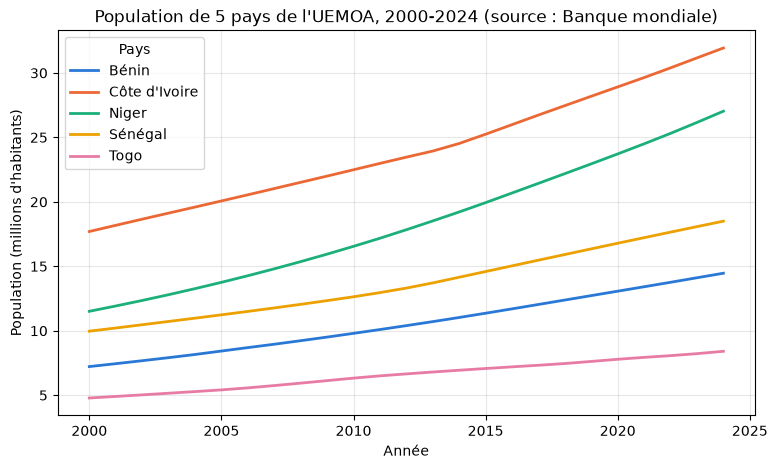

In [35]:
quelques_pays = ["BEN", "CIV", "NER", "SEN", "TGO"]
extrait = uemoa[uemoa["iso3"].isin(quelques_pays)]
courbes = extrait.pivot(index="annee", columns="pays", values="population") / 1_000_000

courbes.plot(figsize=(9, 5), color=COULEURS, linewidth=2)
plt.legend(title="Pays")
plt.title("Population de 5 pays de l'UEMOA, 2000-2024 (source : Banque mondiale)")
plt.xlabel("Année")
plt.ylabel("Population (millions d'habitants)")
plt.grid(alpha=0.3)
plt.show()

> 💡 Toutes les courbes montent : en 25 ans, la population de chacun de ces pays a environ **doublé** (de × 1,8 à × 2,3). Le Niger, en vert, a la croissance la plus rapide : de 11,5 à 27 millions d'habitants. C'est le genre de constat que l'ONG reprendra dans sa note.

## 10. La météo de la semaine dans 5 villes

Pour préparer les missions terrain, l'ONG veut les prévisions des 7 prochains jours dans 5 grandes villes. Une requête par ville, dans une boucle `for`, **avec une pause** d'une seconde entre deux appels.

On garde les réponses brutes (un dictionnaire ville → JSON) **et** on construit un petit tableau par ville, en ajoutant une colonne `ville`.

In [36]:
VILLES = {                    # ville : (latitude, longitude)
    "Cotonou": (6.37, 2.39),
    "Lomé": (6.13, 1.22),
    "Abidjan": (5.36, -4.01),
    "Dakar": (14.69, -17.44),
    "Bamako": (12.64, -8.00),
}

La boucle : pour chaque ville, on appelle l'API avec `get_poli`, on range la réponse brute, puis on fabrique son tableau. L'écriture `for ville, (latitude, longitude) in VILLES.items()` récupère à chaque tour le nom de la ville et ses deux coordonnées.

In [37]:
reponses_meteo = {}          # brut : ville → réponse JSON
tableaux = []                # propre : un DataFrame par ville
for ville, (latitude, longitude) in VILLES.items():
    params_ville = {"latitude": latitude, "longitude": longitude, "timezone": "auto",
                    "daily": "temperature_2m_max,temperature_2m_min,precipitation_sum"}
    contenu = get_poli(URL_METEO, params_ville).json()
    reponses_meteo[ville] = contenu
    tableau = pd.DataFrame(contenu["daily"])
    tableau["ville"] = ville
    tableaux.append(tableau)
    print(f"{ville} : {len(tableau)} jours")
    time.sleep(1)            # politesse : 1 seconde entre deux villes

Cotonou : 7 jours


Lomé : 7 jours


Abidjan : 7 jours


Dakar : 7 jours


Bamako : 7 jours


`pd.concat` **empile** les 5 tableaux en un seul ; on type la date et on renomme les colonnes comme à la section 2.

In [38]:
meteo = pd.concat(tableaux, ignore_index=True)
meteo["time"] = pd.to_datetime(meteo["time"])
meteo = meteo.rename(columns={"time": "date", "temperature_2m_max": "temp_max_c",
                              "temperature_2m_min": "temp_min_c", "precipitation_sum": "pluie_mm"})
print("Lignes :", len(meteo), "(5 villes × 7 jours)")
meteo.head(8)

Lignes : 35 (5 villes × 7 jours)


,date,temp_max_c,temp_min_c,pluie_mm,ville
0,2026-10-07,29.5,26.1,0.5,Cotonou
1,2026-10-08,28.6,24.9,3.0,Cotonou
2,2026-10-09,29.3,25.3,0.5,Cotonou
3,2026-10-10,28.6,26.1,1.9,Cotonou
4,2026-10-11,29.4,25.8,0.0,Cotonou
5,2026-10-12,29.3,26.2,0.3,Cotonou
6,2026-10-13,29.7,25.7,0.9,Cotonou
7,2026-10-07,30.3,25.1,0.4,Lomé


On sauvegarde le brut (bronze) et le tableau propre (silver), tous deux datés. Comme pour la Banque mondiale, le brut garde sa **traçabilité** : source, date d'extraction et licence (les données d'Open-Meteo sont elles aussi sous licence CC BY 4.0).

In [39]:
dossier_meteo = DOSSIER_BRUT / "open_meteo"
dossier_meteo.mkdir(parents=True, exist_ok=True)
chemin_brut_meteo = dossier_meteo / f"previsions_5_villes_{AUJOURDHUI}.json"
brut_meteo = {"source": URL_METEO, "date_extraction": AUJOURDHUI,
              "licence": "CC BY 4.0 - Open-Meteo", "reponses": reponses_meteo}
chemin_brut_meteo.write_text(json.dumps(brut_meteo, ensure_ascii=False), encoding="utf-8")

chemin_meteo = DOSSIER_PROPRE / f"meteo_5_villes_{AUJOURDHUI}.parquet"
meteo.to_parquet(chemin_meteo, index=False)
print("Brut   :", chemin_brut_meteo)
print("Propre :", chemin_meteo)

Brut   : ../data/raw/api/open_meteo/previsions_5_villes_2026-10-07.json
Propre : ../data/processed/meteo_5_villes_2026-10-07.parquet


Résumé pour la note : température maximale moyenne et cumul de pluie sur la semaine, par ville. Dans `agg`, chaque ligne se lit `nouvelle_colonne=("colonne de départ", "calcul")`, comme un `GROUP BY` en SQL.

In [40]:
resume = meteo.groupby("ville").agg(
    temp_max_moyenne_c=("temp_max_c", "mean"),
    pluie_semaine_mm=("pluie_mm", "sum"),
)
resume.round(1).sort_values("pluie_semaine_mm", ascending=False)

,temp_max_moyenne_c,pluie_semaine_mm
ville,,
Abidjan,28.3,42.7
Dakar,29.9,36.5
Bamako,31.0,26.6
Cotonou,29.2,7.1
Lomé,30.3,6.0


Et un graphique simple : la température maximale prévue, jour par jour, dans chaque ville.

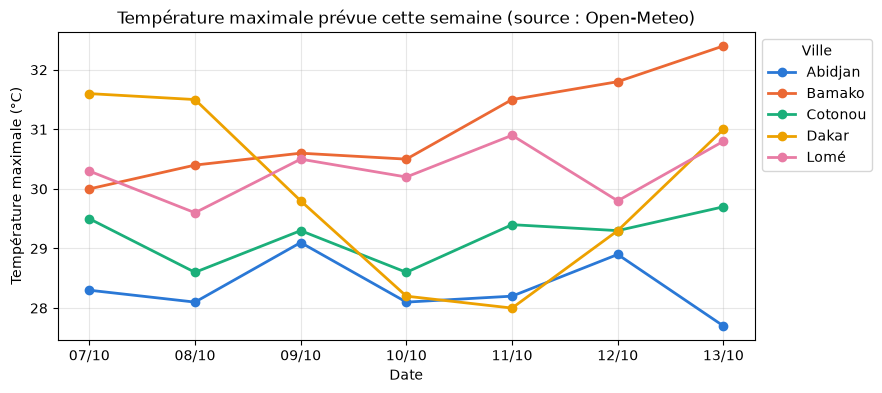

In [41]:
courbes_meteo = meteo.pivot(index="date", columns="ville", values="temp_max_c")
courbes_meteo.index = courbes_meteo.index.strftime("%d/%m")     # dates au format jour/mois

courbes_meteo.plot(figsize=(9, 4), color=COULEURS, linewidth=2, marker="o")
plt.legend(title="Ville", loc="upper left", bbox_to_anchor=(1, 1))   # légende à droite du graphique
plt.title("Température maximale prévue cette semaine (source : Open-Meteo)")
plt.xlabel("Date")
plt.ylabel("Température maximale (°C)")
plt.grid(alpha=0.3)
plt.show()

## 11. Pour aller vers les API privées : clé d'API, autres paginations, incrémental

### 11.1 S'authentifier avec une clé d'API

Beaucoup d'API demandent une **clé d'API** : une longue chaîne secrète qui identifie votre programme (un peu comme un mot de passe). Si elle manque ou est fausse : code **401** ; si elle n'a pas les droits : **403**. Trois règles :
- la clé ne s'écrit **jamais** dans le code ni dans le notebook (il est publié sur GitHub !) : elle va dans le fichier **`.env`**, non versionné, exactement comme les mots de passe PostgreSQL et MongoDB ;
- on la transmet de préférence dans un **en-tête** (`Authorization: Bearer <clé>` ou `X-API-Key: <clé>`, selon la documentation de l'API), plutôt que dans l'URL : les URL se retrouvent dans les journaux des serveurs et l'historique du navigateur ;
- on ne l'affiche jamais (sorties de cellules, captures d'écran).

Exemple **sans appel réel**, pour une API privée imaginaire : sa clé serait rangée dans `.env` sur une ligne `MA_CLE_API=...`. Cette variable n'existe pas dans notre `.env` : `os.getenv` renvoie alors la valeur par défaut, une clé factice.

In [42]:
load_dotenv()                 # lit le fichier .env (à la racine du dépôt)
cle_api = os.getenv("MA_CLE_API", "cle-factice-pour-la-demo")

en_tetes_avec_cle = {"User-Agent": EN_TETES["User-Agent"], "Authorization": f"Bearer {cle_api}"}
# Appel réel (non exécuté ici) :
# requests.get(url_api_privee, params=..., headers=en_tetes_avec_cle, timeout=DELAI_MAX)

print("Clé définie dans .env :", "MA_CLE_API" in os.environ)
en_tetes_a_afficher = dict(en_tetes_avec_cle)
en_tetes_a_afficher["Authorization"] = "Bearer ***"      # on masque AVANT d'afficher
print("En-têtes qui seraient envoyés :", en_tetes_a_afficher)

Clé définie dans .env : False
En-têtes qui seraient envoyés : {'User-Agent': 'cours-AMA (TP Sources de donnees ; usage pedagogique)', 'Authorization': 'Bearer ***'}


### 11.2 Les différents types de pagination

La Banque mondiale pagine **par numéro de page**. Vous rencontrerez aussi d'autres façons de faire :

| Type | Ce qu'on envoie | Comment savoir s'il reste des données ? | Exemples |
|---|---|---|---|
| **Numéro de page** | `page=2&per_page=50` | `meta.pages` donne le nombre de pages | Banque mondiale |
| **Décalage** (*offset / limit*) | `offset=100&limit=50` (« saute 100 lignes, donne-m'en 50 ») | on s'arrête quand une page revient vide ou incomplète | nombreuses API ; `LIMIT … OFFSET …` en SQL |
| **Curseur** | `cursor=dXNlcjpXMDdRQ1JQQTQ=` : un jeton renvoyé par la page précédente | la réponse ne contient plus de « curseur suivant » | Slack, Stripe |
| **En-tête `Link`** | rien à calculer : l'URL de la page suivante est fournie | l'en-tête `Link` ne contient plus `rel="next"` | GitHub (`requests` le lit dans `reponse.links`) |

> 💡 Un **curseur** est un marqueur de position : « reprends juste après cet élément ». Il évite les doublons et les oublis quand les données changent pendant qu'on pagine, ce que la pagination par page ou par décalage ne garantit pas.

### 11.3 Extraction incrémentale côté API

Rappel du cours : une extraction **complète** reprend tout à chaque fois ; une extraction **incrémentale** ne demande que ce qui est nouveau depuis la dernière fois (l'équivalent de la borne `maj_le > ?` en SQL). Côté API, on le fait avec des paramètres de filtre :
- `date=2020:2024` : une plage d'années ;
- `mrv=5` (*most recent values*) : les 5 valeurs les plus récentes ;
- sur d'autres API : `updated_since=2026-10-01`, `since=…`, etc.

Exemple : les 5 dernières valeurs de la population du Bénin, en une seule petite requête au lieu de tout l'historique.

In [43]:
url_benin = "https://api.worldbank.org/v2/fr/country/BJ/indicator/SP.POP.TOTL"
dernieres = aplatir_bm(recuperer_toutes_les_pages(url_benin, {"format": "json", "mrv": 5}))
dernieres

  page 1/1 : 5 lignes


Terminé : 5 lignes (total annoncé : 5)


,pays,iso3,annee,valeur
0,Bénin,BEN,2021,13413417.0
1,Bénin,BEN,2022,13759501.0
2,Bénin,BEN,2023,14111034.0
3,Bénin,BEN,2024,14462724.0
4,Bénin,BEN,2025,14814460.0


> 💡 Regardez la dernière année : elle peut être **plus récente** que la fin de notre extraction (2024). C'est exactement ce qu'une extraction incrémentale va chercher. Pour un vrai pipeline : on mémorise la dernière année déjà reçue, la prochaine extraction ne demande que la suite (`date=<dernière année + 1>:<année en cours>`), puis on ajoute les nouvelles lignes au fichier existant **sans doublons**.

## 12. Exercices

Les solutions sont incluses sous chaque énoncé : essayez d'abord sans les regarder !

### ✍️ Exercice 1 — Le taux d'urbanisation du Bénin

L'ONG veut ajouter à sa note le **taux d'urbanisation** du Bénin (`SP.URB.TOTL.IN.ZS` : % de la population vivant en ville), de 2000 à 2024.

1. Récupérez-le avec `recuperer_toutes_les_pages` et `aplatir_bm`.
2. Affichez le taux en 2000 et en 2024.
3. En quelle année le Bénin a-t-il dépassé **50 %** de population urbaine ?

In [44]:
# ✅ Solution
url_urbanisation = "https://api.worldbank.org/v2/fr/country/BJ/indicator/SP.URB.TOTL.IN.ZS"
urbanisation = aplatir_bm(recuperer_toutes_les_pages(url_urbanisation, PARAMS_BM))

taux_2000 = urbanisation[urbanisation["annee"] == 2000]["valeur"].iloc[0]
taux_2024 = urbanisation[urbanisation["annee"] == 2024]["valeur"].iloc[0]
premiere_annee = urbanisation[urbanisation["valeur"] > 50]["annee"].min()
print(f"Taux d'urbanisation en 2000 : {taux_2000:.1f} %")
print(f"Taux d'urbanisation en 2024 : {taux_2024:.1f} %")
print("Première année au-dessus de 50 % :", premiere_annee)

  page 1/1 : 25 lignes


Terminé : 25 lignes (total annoncé : 25)
Taux d'urbanisation en 2000 : 38.3 %
Taux d'urbanisation en 2024 : 52.5 %
Première année au-dessus de 50 % : 2021


### ✍️ Exercice 2 — Combien de pages avec `per_page=10` ?

Pour la population des 8 pays (200 lignes), combien de pages faut-il si l'API renvoie **10 lignes par page** ?

1. Calculez-le d'abord (indice : `math.ceil` arrondit à l'entier supérieur).
2. Vérifiez en demandant **seulement la page 1** : inutile de télécharger les 20 pages, les métadonnées suffisent.
3. Question : quel est l'inconvénient d'un `per_page` trop petit ? Et trop grand ?

In [45]:
# ✅ Solution
total_lignes = 200
print("Calcul         :", math.ceil(total_lignes / 10), "pages")

params_10 = {"format": "json", "date": "2000:2024", "per_page": 10, "page": 1}
meta_10, lignes_10 = verifier_reponse_bm(get_poli(URL_POPULATION, params_10).json())
print("D'après l'API  :", meta_10["pages"], "pages de", meta_10["per_page"], "lignes, total", meta_10["total"])

# 3. Trop petit : beaucoup de requêtes (20 au lieu de 4) → plus lent et plus de charge pour le serveur.
#    Trop grand : réponses énormes → risque de dépasser le délai maximal ; certaines API plafonnent per_page.

Calcul         : 20 pages


D'après l'API  : 20 pages de 10 lignes, total 200


### ✍️ Exercice 3 — Détecter les codes pays invalides

Un collègue vous envoie une liste de codes à interroger : `["SN", "TG", "XX", "SEN", "Benin", "GN"]`.

Pour chacun, demandez la population en 2024 (`date=2024`) avec `get_poli`, puis utilisez `verifier_reponse_bm` dans un `try / except` pour afficher :
- « valide » (avec le nom du pays renvoyé par l'API),
- « aucune donnée » (liste de lignes vide),
- ou « invalide » (message d'erreur de l'API).

Deux surprises vous attendent : un code à 3 lettres fonctionne, et un code valide n'est pas celui qu'on croit. Lesquels ?

In [46]:
# ✅ Solution
codes_a_tester = ["SN", "TG", "XX", "SEN", "Benin", "GN"]
for code_pays in codes_a_tester:
    url_pays = f"https://api.worldbank.org/v2/fr/country/{code_pays}/indicator/SP.POP.TOTL"
    reponse_pays = get_poli(url_pays, {"format": "json", "date": "2024"})
    try:
        meta_pays, lignes_pays = verifier_reponse_bm(reponse_pays.json())
        if len(lignes_pays) == 0:
            print(f"{code_pays} → aucune donnée (code accepté mais inconnu)")
        else:
            print(f"{code_pays} → valide : {lignes_pays[0]['country']['value']}")
    except ValueError as erreur:
        print(f"{code_pays} → invalide : {erreur}")
    time.sleep(0.5)

# Surprise 1 : 'SEN' fonctionne, car l'API accepte aussi les codes ISO à 3 lettres.
# Surprise 2 : 'GN' est la Guinée (Conakry), pas la Guinée-Bissau ('GW') : un code valide n'est pas forcément le bon !

SN → valide : Sénégal


TG → valide : Togo


XX → aucune donnée (code accepté mais inconnu)


SEN → valide : Sénégal


Benin → invalide : erreur de l'API : The provided parameter value is not valid


GN → valide : Guinée


### ✍️ Exercice 4 — Températures heure par heure à Abomey-Calavi

Un atelier a lieu aujourd'hui à Abomey-Calavi (latitude 6.45, longitude 2.35). Récupérez la température **heure par heure** pour la journée avec Open-Meteo (paramètres `hourly="temperature_2m"` et `forecast_days=1`, sans oublier `timezone="auto"`).

1. Construisez un DataFrame à partir de `contenu["hourly"]` (combien de lignes ?).
2. À quelle heure fera-t-il le plus chaud ? (indice : `idxmax()` donne le numéro de la ligne du maximum.)
3. Quel est l'écart entre la température maximale et la minimale de la journée ?

In [47]:
# ✅ Solution
params_calavi = {"latitude": 6.45, "longitude": 2.35, "hourly": "temperature_2m",
                 "forecast_days": 1, "timezone": "auto"}
contenu_calavi = get_poli(URL_METEO, params_calavi).json()

horaire = pd.DataFrame(contenu_calavi["hourly"])
horaire["time"] = pd.to_datetime(horaire["time"])
ligne_max = horaire.loc[horaire["temperature_2m"].idxmax()]
ecart = horaire["temperature_2m"].max() - horaire["temperature_2m"].min()

print("Nombre d'heures :", len(horaire))
print("Le plus chaud   :", ligne_max["temperature_2m"], "°C à", ligne_max["time"].strftime("%H:%M"))
print(f"Écart max - min : {ecart:.1f} °C")

Nombre d'heures : 24
Le plus chaud   : 29.2 °C à 14:00
Écart max - min : 4.3 °C


### ✍️ Exercice 5 — Export CSV pour les collègues sous Excel

Les collègues de l'ONG travaillent avec Excel en français. Exportez le tableau `uemoa` en CSV dans `../data/processed/`, avec la date du jour dans le nom du fichier, et avec :
- le séparateur `;` et la virgule comme séparateur décimal (`sep=";"`, `decimal=","`) ;
- l'encodage `utf-8-sig`, pour qu'Excel affiche correctement les accents.

Relisez ensuite le fichier avec `pd.read_csv` (mêmes options) pour vérifier le nombre de lignes. Comparez la taille du CSV à celle du Parquet de la section 9.

In [48]:
# ✅ Solution
chemin_csv = DOSSIER_PROPRE / f"uemoa_population_pib_2000_2024_{AUJOURDHUI}.csv"
uemoa.to_csv(chemin_csv, sep=";", decimal=",", index=False, encoding="utf-8-sig")

relu_csv = pd.read_csv(chemin_csv, sep=";", decimal=",", encoding="utf-8-sig")
print("Lignes relues :", len(relu_csv))
print(f"Taille CSV     : {chemin_csv.stat().st_size / 1024:.1f} Ko")
print(f"Taille Parquet : {chemin_parquet.stat().st_size / 1024:.1f} Ko")
# Sur 200 lignes, l'écart est faible ; sur des millions de lignes, le Parquet est
# bien plus léger. Et lui seul garde les types (le CSV n'est que du texte).
relu_csv.head(3)

Lignes relues : 200
Taille CSV     : 9.1 Ko
Taille Parquet : 6.9 Ko


,pays,iso3,annee,population,pib_par_habitant_usd
0,Bénin,BEN,2000,7221619.0,487.424141
1,Bénin,BEN,2001,7445596.0,492.401500
2,Bénin,BEN,2002,7675426.0,546.463830


## Récapitulatif

**Ce que vous avez fait**
- interrogé deux API REST publiques (Open-Meteo, Banque mondiale) avec `requests.get(url, params=…, headers=…, timeout=…)` ;
- lu le code HTTP, les en-têtes et le JSON d'une réponse, et provoqué des erreurs 400 et 404 ;
- détecté une erreur cachée derrière un code 200 ;
- récupéré toutes les pages d'un résultat paginé, avec pauses et nouveaux essais ;
- produit les livrables de l'ONG : JSON bruts datés (bronze) et tableaux Parquet propres (silver), plus deux graphiques.

**Les réflexes à retenir**
- toujours un **`timeout`** et un **User-Agent** explicite ;
- passer les paramètres avec `params=` plutôt que de construire l'URL à la main ;
- vérifier le **code HTTP** (`raise_for_status()`) **et** le **contenu** : un 200 peut cacher une erreur ;
- paginer **jusqu'au bout** et vérifier que le nombre de lignes = `total` annoncé ;
- être poli : **pauses** entre les requêtes, nouveaux essais avec attente croissante, respect de `Retry-After` en cas de 429 ;
- garder le **brut daté** avec sa source et sa licence, puis produire un fichier **propre et typé** ;
- les clés d'API vont dans **`.env`**, jamais dans le code ni dans les sorties.

## Pour aller plus loin

- **`requests.Session()`** : une session garde la connexion ouverte entre deux requêtes (plus rapide quand on enchaîne les pages) et permet de définir les en-têtes une seule fois.
- **Moins d'appels** : Open-Meteo accepte plusieurs lieux en une seule requête (`latitude=6.37,14.69&longitude=2.39,-17.44`) ; la réponse est alors une liste, un élément par lieu.
- **Extraction incrémentale** : relisez le Parquet de la section 9, trouvez la dernière année présente, ne demandez que la suite (`date=`), puis concaténez sans doublons (`drop_duplicates`).
- **SQL sur le Parquet** : chargez le fichier dans DuckDB (`SELECT … FROM 'fichier.parquet'`) et calculez la croissance de la population par pays entre 2000 et 2024.
- Documentation : [API de la Banque mondiale](https://datahelpdesk.worldbank.org/knowledgebase/topics/125589-developer-information) · [Open-Meteo](https://open-meteo.com/en/docs).